In [1]:
import pandas as pd
import numpy as np
import sys
from numba import njit, prange
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.metrics.fidelity.utils import extract_metadata
metadata_path = "../../Data/data_processed/Original_data/feature_metadata.json"
data_path = "../../Data/data_processed/Original_data/integrated_data_jobim.csv"

or_df = pd.read_csv("../../Data/data_processed/Original_data/integrated_data_jobim.csv", index_col = 0)
metadata = extract_metadata(or_df, metadata_path)
categorical_features = metadata.get("ordinal_categorical") + metadata.get("dummy_categorical") + metadata.get("missing_categorical")
numerical_features = metadata.get("numerical")

In [2]:
print(f"Number of dummy cols {len(metadata.get('dummy_categorical'))}")
print(f"Number of ordinal cols {len(metadata.get('ordinal_categorical'))}")
print(f"Number of numerical cols {len(metadata.get('numerical'))}")
print(f"Number of missing indicators {len(metadata.get('missing_categorical'))}")
print(f"Number of columns {len(categorical_features)+len(numerical_features)}")

Number of dummy cols 10
Number of ordinal cols 3
Number of numerical cols 40937
Number of missing indicators 6
Number of columns 40956


In [3]:
from sklearn.preprocessing import LabelEncoder
def encode_categorical_columns(data: pd.DataFrame, categorical_columns: list):
    """
    Encode multiple categorical columns in a DataFrame using LabelEncoder.

    Args:
        data (pd.DataFrame): The DataFrame containing the data to be encoded.
        categorical_columns (list): List of column names to encode.

    Returns:
        pd.DataFrame: DataFrame with categorical columns encoded as integers.
        dict: A dictionary mapping column names to their LabelEncoders.

    Raises:
        ValueError: If a specified column does not exist in the DataFrame.
    """
    encoders = {}
    encoded_data = data.copy()

    for col in categorical_columns:
        if col not in encoded_data.columns:
            raise ValueError(f"Column '{col}' not found in the DataFrame.")
        
        encoder = LabelEncoder()
        encoded_data[col] = encoder.fit_transform(encoded_data[col].astype(str))
        encoders[col] = encoder

    return encoded_data, encoders

encoded_cat_df, encoders = encode_categorical_columns(or_df[categorical_features], categorical_features)

In [3]:
from sklearn.preprocessing import StandardScaler
import pickle
def normalization(data: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(data, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")
    try:  
        scaler = StandardScaler()
        scaled_num_df = scaler.fit_transform(data)
        with open("avatar_normalizationer.pkl", "wb") as f:
            pickle.dump(scaler, f)
        scaled_num_df = pd.DataFrame(scaled_num_df, columns = data.columns, index = data.index)
        return scaled_num_df
    except Exception as e: 
        raise ValueError(f"Error in normalizing numerical features: {e}")


num_df = or_df[numerical_features]
scaled_num_df = normalization(num_df)
scaled_num_df.head()

,PFS,OS,Age,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
Patient_ID,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.442346,-0.057158,0.015438,-0.830622,0.369811,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,-0.456877,-0.073693,-1.660184,-1.010088,0.406583,0.016714,-0.451830,-0.314134,0.014564,-1.892162
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,-0.190070,0.491514,0.497567,0.661023,0.307975,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,0.976433,0.975964,0.625872,1.262803,0.869441,0.016714,0.812325,0.648156,0.014564,1.110525
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,5.155865,2.063295,0.015438,0.161379,-0.989567,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,0.570333,0.328262,0.377905,0.661102,0.633969,0.016714,0.653854,0.314914,0.014564,0.732038
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,-0.591950,-1.228732,-0.177414,-0.830622,-1.100268,-0.241128,-0.12091,0.018994,0.02812,1.423996,...,0.207209,0.167725,0.566153,1.241272,0.460550,0.016714,0.690214,0.367474,0.014564,0.511579
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,-0.174493,1.838986,1.365399,-0.830622,-0.469457,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,-2.665545,-1.862492,-1.660184,-1.010088,-0.367736,0.016714,-1.342956,-2.266501,0.014564,-1.892162


In [4]:
processed_df = pd.concat([encoded_cat_df, scaled_num_df], axis = 1)
# processed_df.to_csv("ForSynthpop_processed_df.csv", index= True)

NameError: name 'encoded_cat_df' is not defined

## **2. Correlation Calculation**

In [7]:
from SynOmics.utils import get_column_indices
from SynOmics.Preprocess.Correlations import MixedCorrelation
# from utils import split_clusters_by_size
from scipy.cluster.hierarchy import ward, fcluster, average


categorical_indices = get_column_indices(processed_df, categorical_features)
numerical_indices = get_column_indices(processed_df, numerical_features)

compute_correlations = MixedCorrelation(categorical_indices, numerical_indices, method = "spearman", n_bins = 10)
corr_matrix = compute_correlations.compute(processed_df)
distance_matrix = 1 - np.abs(corr_matrix)
# sqr_corr_mat = MixedCorrelation.get_squareform(distance_matrix)
# Z = average(sqr_corr_mat.astype(np.float64))
#Save Z
# np.save("Z.npy", Z)

In [8]:
import numpy as np
import pandas as pd

def binary_correlation_matrix(dist_matrix, threshold, max_per_row=3000):
    """
    Create a binary matrix from a correlation matrix using a threshold.

    Each cell in the matrix is set to 1 if its value is less than the given threshold,
    otherwise it is set to 0. For each row, if the number of 1s exceeds max_per_row,
    only the top max_per_row lowest values are set to 1 and the rest are set to 0.

    Args:
        corr_matrix (Union[np.ndarray, pd.DataFrame]): Input correlation matrix.
        threshold (float): Threshold below which cells are considered satisfied (set to 1).
        max_per_row (int, optional): Maximum number of 1s allowed per row (default is 3000).

    Returns:
        np.ndarray: Binary matrix of the same shape as corr_matrix.

    Raises:
        ValueError: If the input is not a 2D array or DataFrame.
    """
    # Convert to numpy array if dataframe
    if isinstance(dist_matrix, pd.DataFrame):
        arr = dist_matrix.values
    elif isinstance(dist_matrix, np.ndarray):
        arr = dist_matrix
    else:
        raise ValueError("Input must be a numpy array or pandas DataFrame.")

    # Step 1: Apply thresholding
    bin_matrix = (arr <= threshold).astype(int)

    # Step 2: For each row, keep only top max_per_row lowest values as 1 if exceeding the limit
    for i in range(bin_matrix.shape[0]):
        ones_indices = np.where(bin_matrix[i] == 1)[0]
        if len(ones_indices) > max_per_row:
            # Get indices of the actual lowest values (not just any cell < threshold)
            row_values = arr[i, ones_indices]
            lowest_indices = ones_indices[np.argsort(row_values)[:max_per_row]]
            # Reset all to 0, then set only the lowest ones to 1
            bin_matrix[i, ones_indices] = 0
            bin_matrix[i, lowest_indices] = 1

    return bin_matrix
distance_matrix_binarized = distance_matrix.copy()
features = processed_df.columns.tolist()
threshold = 0.5
max_per_row = 3000
binary_matrix = binary_correlation_matrix(distance_matrix_binarized, threshold, max_per_row)

In [36]:
import json
import numpy as np

def convert(o):
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError


with open("my_dict.json", "w") as f:
    json.dump(result, f, default=convert)

In [9]:
anchors = []
anchors_set = set(anchors)
anchors_indices = [features.index(feature) for feature in features if feature in anchors_set]
features_without_anchors_indices = [features.index(feature) for feature in features if feature not in anchors_set]

result = {
    str(idx): [
        i for i in np.where(binary_matrix[idx] == 1)[0] 
        if i != idx and i not in anchors_indices
    ]
    for idx in features_without_anchors_indices
}

# Sort the dictionary by the length of the value lists (descending order)
sorted_result = dict(sorted(result.items(), key=lambda item: len(item[1]), reverse=False))

In [11]:
counts = [len(value) for key, value in sorted_result.items()]

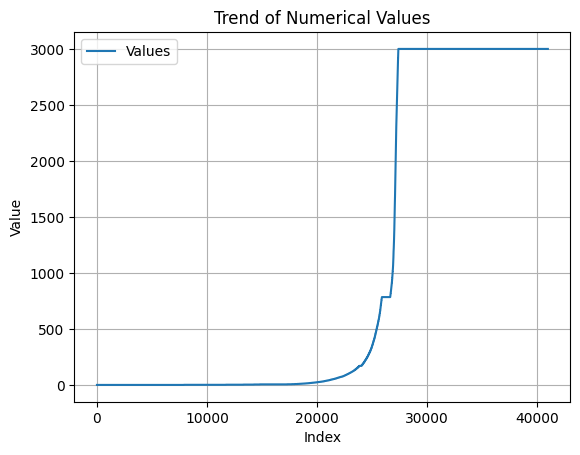

In [13]:
import matplotlib.pyplot as plt


# Line plot
plt.plot(counts, linestyle='-', label='Values')

# Add labels
plt.title("Trend of Numerical Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
from collections import defaultdict
import heapq

items = list(sorted_result.items())
length_groups = defaultdict(list)
for i, (k,v) in enumerate(items):
    length_groups[len(v)].append((k, v, i)) 
    
# Assume items = list(sorted_result.items())
length_groups = defaultdict(list)
for i, (k, v) in enumerate(items):
    length_groups[len(v)].append((k, set(v), i))  # store v as set for fast lookup

advanced_results = []
prev_keys = set()

for length in sorted(length_groups.keys()):
    all_prev_keys = prev_keys.copy()
    group = length_groups[length]

    # Precompute overlap count with all_prev_keys for each item
    overlap_counts = []
    for item in group:
        _, v, _ = item
        overlap = len(v & all_prev_keys)
        overlap_counts.append(overlap)

    # Use heap to always pop the item with the highest overlap
    heap = [(-overlap, idx, item) for idx, (overlap, item) in enumerate(zip(overlap_counts, group))]
    heapq.heapify(heap)
    used_keys = set()

    while heap:
        neg_overlap, _, (k, v, idx) = heapq.heappop(heap)
        # Optionally apply a secondary tie-breaker if needed
        advanced_results.append((k, list(v)))
        prev_keys.add(int(k))
        used_keys.add(int(k))

advanced_results_dict = dict(advanced_results)

In [15]:
sorted_count = []
for key, value in advanced_results_dict.items():
    sorted_count.append(len(value))

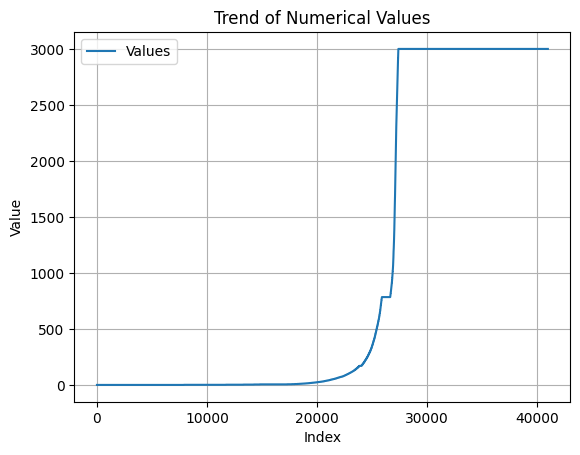

In [17]:
import matplotlib.pyplot as plt


# Line plot
plt.plot(sorted_count, linestyle='-', label='Values')

# Add labels
plt.title("Trend of Numerical Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
def redesign_matrix_with_anchors(num_features, anchors, sorted_dict):
    """
    Redesign the binary matrix for Synthpop guidance with anchors as predictors for all features.
    Ensure strictly lower-triangular form (no predictors after diagonal).
    """
    # Final order = anchors first, then features in sorted_dict order
    feature_order = anchors + [int(k) for k in sorted_dict.keys()]
    order_map = {old: new for new, old in enumerate(feature_order)}
    n = len(feature_order)

    # Initialize matrix
    mat = np.zeros((n, n), dtype=int)

    # Fill anchors triangular structure
    for i in range(len(anchors)):
        for j in range(i):
            mat[i, j] = 1

    # Fill non-anchor features
    for f_str, correlated in sorted_dict.items():
        f = int(f_str)
        row = order_map[f]
        # 1) set all anchors as predictors (only if before this row)
        for a in range(len(anchors)):
            if a < row:
                mat[row, a] = 1
        # 2) set correlated features as predictors (only if before this row)
        for c in correlated:
            if c in order_map:
                col = order_map[c]
                if col < row:   # ensure lower-triangular
                    mat[row, col] = 1

    return mat, feature_order

# Example usage
anchors_indices = []
sorted_dict = advanced_results_dict
num_features = len(sorted_count)
mat, order = redesign_matrix_with_anchors(num_features, anchors_indices, sorted_dict)

In [22]:
mat_counts = [np.sum(mat[i,:]) for i in range(mat.shape[0])]

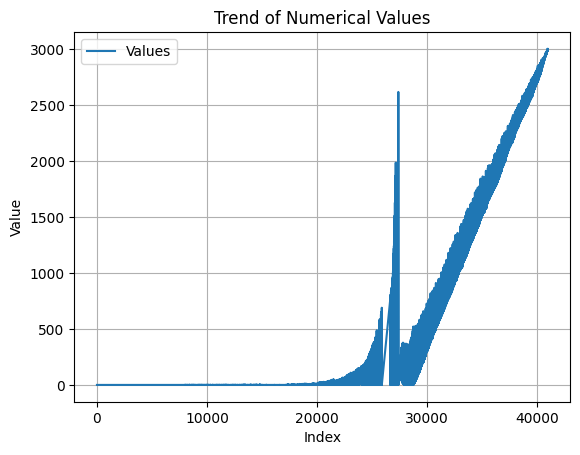

In [23]:
import matplotlib.pyplot as plt


# Line plot
plt.plot(mat_counts, linestyle='-', label='Values')

# Add labels
plt.title("Trend of Numerical Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [84]:
with open('order_pred_mat.txt', 'w') as f:
    for item in order:
        f.write(f"{item}\n")

In [81]:
np.save("predictor_matrix.npy", mat)